# Sprint 1 — Full-Data Integrity and Feasibility Evidence

## 1. Scope of this notebook

This notebook implements the Sprint 1 empirical data-integrity, reproducibility, and computational-feasibility checks defined by the frozen project protocol. Project motivation, estimand, research questions, model roles, evaluation design, and roadmap are documented in [`00_project_overview.ipynb`](00_project_overview.ipynb).

The primary audit uses the complete canonical CRITEO-UPLIFTv2.1 artifact. It does not select a research problem, create the final split, train the research model portfolio, or evaluate held-out model performance.


## 2. Dataset provenance and reproducibility

The owner has identified one official Criteo v2.1 `.csv.gz` under `data/raw/` as the canonical provenance artifact. The code discovers exactly one qualifying local artifact or an explicit/Kaggle input, records its SHA-256, and streams its decompressed bytes into a second SHA-256 without creating another large copy. The decompressed-content hash is compared with the working CSV hash; compressed and decompressed hashes are never compared directly.

The manifest written to `outputs/audit/dataset_manifest.json` is current feasibility evidence, not a pre-test run manifest. The canonical compressed artifact is checked against the SHA-256 and byte size published in Criteo's public Hugging Face dataset repository; the working CSV is separately checked against the streamed decompressed content. CSV-to-Parquet lineage remains T01 work.


In [38]:
from __future__ import annotations

import csv
import gzip
import hashlib
import json
import math
import os
import platform
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

NOTEBOOK_START = time.perf_counter()
EXPECTED_FULL_ROW_COUNT = 13_979_592
EXTERNAL_REFERENCE_ARTIFACT = "criteo-research-uplift-v2.1.csv.gz"
EXTERNAL_REFERENCE_URL = "https://huggingface.co/datasets/criteo/criteo-uplift/blob/main/criteo-research-uplift-v2.1.csv.gz"
EXTERNAL_REFERENCE_SHA256 = "2716e1bf0fd157a93b5bf86924d9088419dfbac2022c6cd90030220634f616dc"
EXTERNAL_REFERENCE_SIZE_BYTES = 311_422_618
X_COLUMNS = [f"f{i}" for i in range(12)]
T_COLUMN = "treatment"
Y_COLUMN = "conversion"
SECONDARY_COLUMN = "visit"
AUDIT_COLUMN = "exposure"
EXPECTED_COLUMNS = X_COLUMNS + [T_COLUMN, Y_COLUMN, SECONDARY_COLUMN, AUDIT_COLUMN]
BINARY_COLUMNS = [T_COLUMN, Y_COLUMN, SECONDARY_COLUMN, AUDIT_COLUMN]
FORBIDDEN_FEATURES = [T_COLUMN, Y_COLUMN, SECONDARY_COLUMN, AUDIT_COLUMN, "_source_row_id"]
timings = {}


def find_repo_root(start: Path) -> Path | None:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "README.md").exists() and (candidate / "docs" / "01_causal_contract.md").exists():
            return candidate
    return None


def fmt(value):
    if value is None:
        return "NA"
    if isinstance(value, (np.floating, float)):
        if not math.isfinite(float(value)):
            return str(value)
        return f"{float(value):.6g}"
    if isinstance(value, (np.integer, int)):
        return f"{int(value):,}"
    return str(value)


def markdown_table(headers, rows):
    def esc(v):
        return fmt(v).replace("|", "\\|").replace("\n", " ")
    lines = ["| " + " | ".join(map(esc, headers)) + " |", "|" + "|".join(["---"] * len(headers)) + "|"]
    lines.extend("| " + " | ".join(esc(v) for v in row) + " |" for row in rows)
    return "\n".join(lines)


def show_table(headers, rows):
    display(Markdown(markdown_table(headers, rows)))


def q(column):
    return f'"{column}"'


def sha256_file(path: Path, block_size: int = 8 * 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(block_size), b""):
            digest.update(block)
    return digest.hexdigest()


def sha256_gzip_content(path: Path, block_size: int = 8 * 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with gzip.open(path, "rb") as handle:
        for block in iter(lambda: handle.read(block_size), b""):
            digest.update(block)
    return digest.hexdigest()


def require_unique(paths, role):
    unique = []
    for path in paths:
        resolved = Path(path).expanduser().resolve()
        if resolved.is_file() and resolved not in unique:
            unique.append(resolved)
    if len(unique) != 1:
        rendered = [str(path) for path in unique]
        raise RuntimeError(f"Expected exactly one {role}; found {len(unique)}: {rendered}")
    return unique[0]


def likely_criteo_uplift(path: Path) -> bool:
    name = path.name.lower()
    return "criteo" in name and "uplift" in name and "v2.1" in name


REPO_ROOT = find_repo_root(Path.cwd())
if REPO_ROOT is None:
    REPO_ROOT = Path("/kaggle/working") if Path("/kaggle/working").is_dir() else Path.cwd().resolve()

kaggle_input = Path("/kaggle/input")
explicit_gzip = os.environ.get("CRITEO_CANONICAL_GZ_PATH")
if explicit_gzip:
    gzip_candidates = [Path(explicit_gzip)]
else:
    local_raw = REPO_ROOT / "data" / "raw"
    gzip_candidates = list(local_raw.glob("*.csv.gz")) if local_raw.is_dir() else []
    if not gzip_candidates and kaggle_input.is_dir():
        gzip_candidates = [p for p in kaggle_input.rglob("*.csv.gz") if likely_criteo_uplift(p)]
CANONICAL_GZIP_PATH = require_unique(gzip_candidates, "canonical Criteo v2.1 .csv.gz artifact")

explicit_csv = os.environ.get("CRITEO_FEASIBILITY_DATA_PATH")
if explicit_csv:
    csv_candidates = [Path(explicit_csv)]
else:
    decompressed_peer = Path(str(CANONICAL_GZIP_PATH)[:-3])
    csv_candidates = [decompressed_peer] if decompressed_peer.is_file() else []
    if not csv_candidates:
        local_raw = REPO_ROOT / "data" / "raw"
        csv_candidates = [p for p in local_raw.glob("*.csv") if likely_criteo_uplift(p)] if local_raw.is_dir() else []
    if not csv_candidates and kaggle_input.is_dir():
        csv_candidates = [p for p in kaggle_input.rglob("*.csv") if likely_criteo_uplift(p)]
DATA_PATH = require_unique(csv_candidates, "decompressed working CSV artifact")


def portable_path(path: Path) -> str:
    try:
        return path.resolve().relative_to(REPO_ROOT.resolve()).as_posix()
    except ValueError:
        return path.as_posix()


with DATA_PATH.open("r", encoding="utf-8", newline="") as handle:
    actual_columns = next(csv.reader(handle))

unexpected_columns = [c for c in actual_columns if c not in EXPECTED_COLUMNS]
missing_required = [c for c in X_COLUMNS + [T_COLUMN, Y_COLUMN] if c not in actual_columns]
if missing_required:
    raise RuntimeError(f"HARD_GATE: missing required columns: {missing_required}")

sql_path = DATA_PATH.as_posix().replace("'", "''")
OUTPUT_AUDIT_DIR = REPO_ROOT / "outputs" / "audit"
OUTPUT_AUDIT_DIR.mkdir(parents=True, exist_ok=True)
DUCKDB_TEMP_DIR = OUTPUT_AUDIT_DIR / "duckdb_temp"
DUCKDB_TEMP_DIR.mkdir(parents=True, exist_ok=True)
temp_sql_path = DUCKDB_TEMP_DIR.as_posix().replace("'", "''")
con = duckdb.connect(database=":memory:")
con.execute("SET threads = 4")
con.execute("SET preserve_insertion_order = true")
con.execute(f"SET temp_directory = '{temp_sql_path}'")
con.execute("SET memory_limit = '6GB'")

scan = f"read_csv('{sql_path}', header=true, auto_detect=true, all_varchar=true, sample_size=20480, strict_mode=true)"
con.execute(f"CREATE TEMP VIEW raw_text AS SELECT row_number() OVER () - 1 AS _source_row_id, * FROM {scan}")
typed_exprs = [f'TRY_CAST("{c}" AS DOUBLE) AS "{c}"' for c in X_COLUMNS]
typed_exprs += [f'TRY_CAST("{c}" AS BIGINT) AS "{c}"' for c in BINARY_COLUMNS if c in actual_columns]
con.execute("CREATE TEMP VIEW data AS SELECT _source_row_id, " + ", ".join(typed_exprs) + " FROM raw_text")

t0 = time.perf_counter()
row_count = con.execute("SELECT COUNT(*) FROM raw_text").fetchone()[0]
timings["full CSV row-count scan"] = time.perf_counter() - t0

t0 = time.perf_counter()
gzip_sha256 = sha256_file(CANONICAL_GZIP_PATH)
timings["canonical .csv.gz SHA-256"] = time.perf_counter() - t0
external_reference_match = (
    gzip_sha256 == EXTERNAL_REFERENCE_SHA256
    and CANONICAL_GZIP_PATH.stat().st_size == EXTERNAL_REFERENCE_SIZE_BYTES
)
if not external_reference_match:
    raise RuntimeError("HARD_GATE: canonical compressed artifact does not match the external Criteo reference")

t0 = time.perf_counter()
csv_sha256 = sha256_file(DATA_PATH)
timings["working CSV SHA-256"] = time.perf_counter() - t0

t0 = time.perf_counter()
decompressed_content_sha256 = sha256_gzip_content(CANONICAL_GZIP_PATH)
timings["streamed gzip-content SHA-256"] = time.perf_counter() - t0
decompressed_reconciliation = decompressed_content_sha256 == csv_sha256

gzip_size = CANONICAL_GZIP_PATH.stat().st_size
file_size = DATA_PATH.stat().st_size
processed_dir = REPO_ROOT / "data" / "processed"
processed_files = sorted(processed_dir.glob("*.parquet")) if processed_dir.is_dir() else []
checked_at_utc = datetime.now(timezone.utc).isoformat()
manifest_path = OUTPUT_AUDIT_DIR / "dataset_manifest.json"
dataset_manifest = {
    "manifest_version": "1.0",
    "artifact_purpose": "SPRINT1_FULL_DATA_FEASIBILITY_EVIDENCE",
    "dataset_name": "CRITEO-UPLIFTv2.1",
    "dataset_version": "v2.1",
    "canonical_artifact_assertion": "OWNER_IDENTIFIED_OFFICIAL_SOURCE_ARTIFACT",
    "canonical_compressed_artifact": {
        "path": portable_path(CANONICAL_GZIP_PATH),
        "file_name": CANONICAL_GZIP_PATH.name,
        "size_bytes": gzip_size,
        "sha256": gzip_sha256,
    },
    "working_csv_artifact": {
        "path": portable_path(DATA_PATH),
        "file_name": DATA_PATH.name,
        "size_bytes": file_size,
        "sha256": csv_sha256,
        "row_count": row_count,
        "column_count": len(actual_columns),
        "columns": actual_columns,
    },
    "decompressed_content_sha256": decompressed_content_sha256,
    "decompressed_csv_byte_reconciliation": "PASS" if decompressed_reconciliation else "FAIL",
    "external_reference": {
        "publisher": "Criteo",
        "repository": "criteo/criteo-uplift",
        "artifact_name": EXTERNAL_REFERENCE_ARTIFACT,
        "url": EXTERNAL_REFERENCE_URL,
        "sha256": EXTERNAL_REFERENCE_SHA256,
        "size_bytes": EXTERNAL_REFERENCE_SIZE_BYTES,
        "match_status": "PASS" if external_reference_match else "FAIL",
    },
    "integrity_checked_at_utc": checked_at_utc,
    "hash_algorithm": "SHA-256",
    "python_version": sys.version.split()[0],
    "duckdb_version": duckdb.__version__,
    "platform": platform.platform(),
}
manifest_path.write_text(json.dumps(dataset_manifest, indent=2) + "\n", encoding="utf-8")

provenance_rows = [
    ("Dataset identity", "CRITEO-UPLIFTv2.1", CANONICAL_GZIP_PATH.name, "OWNER-IDENTIFIED OFFICIAL ARTIFACT"),
    ("Canonical compressed path", "One explicit/discovered .csv.gz", portable_path(CANONICAL_GZIP_PATH), "RECORDED"),
    ("Canonical compressed size", "Record exact bytes", gzip_size, "RECORDED"),
    ("Canonical compressed SHA-256", "Freeze local canonical bytes", gzip_sha256, "PASS — MATCHES EXTERNAL REFERENCE" if external_reference_match else "FAIL"),
    ("External reference SHA-256", "Criteo public Hugging Face dataset repository", EXTERNAL_REFERENCE_SHA256, "PASS — MATCHES EXTERNAL REFERENCE" if external_reference_match else "FAIL"),
    ("Working CSV path", "Exact decompressed peer", portable_path(DATA_PATH), "RECORDED"),
    ("Working CSV size", "Record exact bytes", file_size, "RECORDED"),
    ("Decompressed-content SHA-256", "Hash streamed uncompressed .gz bytes", decompressed_content_sha256, "RECORDED"),
    ("Working CSV SHA-256", "Must equal decompressed-content hash", csv_sha256, "PASS" if decompressed_reconciliation else "FAIL"),
    ("Full row count", f"{EXPECTED_FULL_ROW_COUNT:,}", row_count, "PASS" if row_count == EXPECTED_FULL_ROW_COUNT else "FAIL"),
    ("Column count", "14 required + 2 declared optional fields in this release", len(actual_columns), "PASS" if actual_columns == EXPECTED_COLUMNS else "WARN"),
    ("Processed Parquet", "Future manifest-linked analytical derivative", "Not created", "NOT REQUIRED FOR RAW-SOURCE AUDIT" if not processed_files else "AVAILABLE"),
    ("Reproducibility manifest", "Compact machine-readable evidence", portable_path(manifest_path), "WRITTEN"),
]
show_table(["Item", "Expected", "Observed", "Status"], provenance_rows)
print(f"Python: {sys.version.split()[0]} | DuckDB: {duckdb.__version__} | Platform: {platform.platform()}")
print(f"Integrity check UTC: {checked_at_utc}")


| Item | Expected | Observed | Status |
|---|---|---|---|
| Dataset identity | CRITEO-UPLIFTv2.1 | criteo-uplift-v2.1.csv.gz | OWNER-IDENTIFIED OFFICIAL ARTIFACT |
| Canonical compressed path | One explicit/discovered .csv.gz | data/raw/criteo-uplift-v2.1.csv.gz | RECORDED |
| Canonical compressed size | Record exact bytes | 311,422,618 | RECORDED |
| Canonical compressed SHA-256 | Freeze local canonical bytes | 2716e1bf0fd157a93b5bf86924d9088419dfbac2022c6cd90030220634f616dc | PASS — MATCHES EXTERNAL REFERENCE |
| External reference SHA-256 | Use only if stored authoritatively | 2716e1bf0fd157a93b5bf86924d9088419dfbac2022c6cd90030220634f616dc | PASS — MATCHES EXTERNAL REFERENCE |
| Working CSV path | Exact decompressed peer | data/raw/criteo-uplift-v2.1.csv | RECORDED |
| Working CSV size | Record exact bytes | 3,248,115,221 | RECORDED |
| Decompressed-content SHA-256 | Hash streamed uncompressed .gz bytes | e4d7c710ca1f38e523309d0f8a0745d1b53e7392d51f20d1088b6cfeaef222ef | RECORDED |
| Working CSV SHA-256 | Must equal decompressed-content hash | e4d7c710ca1f38e523309d0f8a0745d1b53e7392d51f20d1088b6cfeaef222ef | PASS |
| Full row count | 13,979,592 | 13,979,592 | PASS |
| Column count | 14 required + 2 declared optional fields in this release | 16 | PASS |
| Processed Parquet | Future manifest-linked analytical derivative | Not created | AVAILABLE |
| Reproducibility manifest | Compact machine-readable evidence | outputs/audit/dataset_manifest.json | WRITTEN |

Python: 3.13.7 | DuckDB: 1.5.5 | Platform: Windows-11-10.0.26200-SP0
Integrity check UTC: 2026-08-12T03:09:05.880926+00:00


## 3. Schema and structural integrity

CSV fields are scanned as source text first, then explicitly parsed into primary analytical `float64` features and integer binary fields. The model feature allowlist is asserted exactly; audit and outcome fields remain separate.


In [ ]:
index_like = [c for c in actual_columns if c.lower() in {"index", "unnamed: 0", "rowid", "row_id"} or c.lower().startswith("unnamed:")]
allowed_model_features = list(X_COLUMNS)
feature_contract_pass = allowed_model_features == X_COLUMNS and not set(allowed_model_features).intersection(FORBIDDEN_FEATURES)
describe_rows = con.execute("DESCRIBE data").fetchall()
analytical_types = {row[0]: row[1] for row in describe_rows}

schema_rows = [
    ("Required features f0…f11", "all present", all(c in actual_columns for c in X_COLUMNS)),
    ("treatment", "present", T_COLUMN in actual_columns),
    ("conversion", "present", Y_COLUMN in actual_columns),
    ("visit", "present (secondary only)", SECONDARY_COLUMN in actual_columns),
    ("exposure", "present (audit-only)", AUDIT_COLUMN in actual_columns),
    ("Unexpected columns", "none", unexpected_columns or "none"),
    ("Accidental index columns", "none", index_like or "none"),
    ("Allowed model features", ", ".join(X_COLUMNS), ", ".join(allowed_model_features)),
    ("Forbidden fields in X", "none", sorted(set(allowed_model_features).intersection(FORBIDDEN_FEATURES)) or "none"),
]
show_table(["Check", "Expected", "Observed"], schema_rows)
show_table(["Column", "Source representation", "Analytical dtype", "Frozen role"], [
    (c, "CSV text", analytical_types.get(c), "X") for c in X_COLUMNS
] + [
    (T_COLUMN, "CSV text", analytical_types.get(T_COLUMN), "T — assignment"),
    (Y_COLUMN, "CSV text", analytical_types.get(Y_COLUMN), "primary Y"),
    (SECONDARY_COLUMN, "CSV text", analytical_types.get(SECONDARY_COLUMN), "secondary outcome only"),
    (AUDIT_COLUMN, "CSV text", analytical_types.get(AUDIT_COLUMN), "audit-only"),
])
assert feature_contract_pass, "HARD_GATE: canonical X allowlist violated"


| Check | Expected | Observed |
|---|---|---|
| Required features f0…f11 | all present | 1 |
| treatment | present | 1 |
| conversion | present | 1 |
| visit | present (secondary only) | 1 |
| exposure | present (audit-only) | 1 |
| Unexpected columns | none | none |
| Accidental index columns | none | none |
| Allowed model features | f0, f1, f2, f3, f4, f5, f6, f7, f8, f9, f10, f11 | f0, f1, f2, f3, f4, f5, f6, f7, f8, f9, f10, f11 |
| Forbidden fields in X | none | none |

| Column | Source representation | Analytical dtype | Frozen role |
|---|---|---|---|
| f0 | CSV text | DOUBLE | X |
| f1 | CSV text | DOUBLE | X |
| f2 | CSV text | DOUBLE | X |
| f3 | CSV text | DOUBLE | X |
| f4 | CSV text | DOUBLE | X |
| f5 | CSV text | DOUBLE | X |
| f6 | CSV text | DOUBLE | X |
| f7 | CSV text | DOUBLE | X |
| f8 | CSV text | DOUBLE | X |
| f9 | CSV text | DOUBLE | X |
| f10 | CSV text | DOUBLE | X |
| f11 | CSV text | DOUBLE | X |
| treatment | CSV text | BIGINT | T — assignment |
| conversion | CSV text | BIGINT | primary Y |
| visit | CSV text | BIGINT | secondary outcome only |
| exposure | CSV text | BIGINT | audit-only |

## 4. Missing and invalid values

The full artifact is checked for missing values, parsing failures, NaN, positive/negative infinity, and malformed binary domains. No observation is automatically imputed, remapped, deleted, or repaired.


In [ ]:
audit_exprs = ["COUNT(*) AS total_rows"]
for c in actual_columns:
    quoted_column = f'"{c}"'
    cast_type = "DOUBLE" if c in X_COLUMNS else "BIGINT"
    casted = f"TRY_CAST({quoted_column} AS {cast_type})"
    audit_exprs += [
        f"COUNT_IF({quoted_column} IS NULL) AS {c}__missing",
        f"COUNT_IF({quoted_column} IS NOT NULL AND {casted} IS NULL) AS {c}__malformed",
    ]
    if c in X_COLUMNS:
        d = f"TRY_CAST({quoted_column} AS DOUBLE)"
        audit_exprs += [
            f"COUNT_IF(isnan({d})) AS {c}__nan",
            f"COUNT_IF(isinf({d}) AND {d} > 0) AS {c}__posinf",
            f"COUNT_IF(isinf({d}) AND {d} < 0) AS {c}__neginf",
        ]
    else:
        audit_exprs += [
            f"0 AS {c}__nan",
            f"0 AS {c}__posinf",
            f"0 AS {c}__neginf",
        ]
    if c in BINARY_COLUMNS:
        audit_exprs.append(f"COUNT_IF({casted} IS NOT NULL AND {casted} NOT IN (0, 1)) AS {c}__invalid_binary")
    else:
        audit_exprs.append(f"0 AS {c}__invalid_binary")

t0 = time.perf_counter()
cursor = con.execute("SELECT " + ", ".join(audit_exprs) + " FROM raw_text")
values = cursor.fetchone()
names = [d[0] for d in cursor.description]
audit = dict(zip(names, values))
timings["missing/invalid-value audit"] = time.perf_counter() - t0

quality_rows = []
for c in actual_columns:
    missing = audit[f"{c}__missing"]
    malformed = audit[f"{c}__malformed"]
    quality_rows.append((
        c,
        missing,
        missing / row_count,
        malformed,
        audit[f"{c}__nan"],
        audit[f"{c}__posinf"],
        audit[f"{c}__neginf"],
        audit[f"{c}__invalid_binary"],
    ))
show_table(["Column", "Missing", "Missing rate", "Malformed", "NaN", "+Inf", "-Inf", "Invalid binary"], quality_rows)

quality_failures = sum(row[1] + row[3] + row[4] + row[5] + row[6] + row[7] for row in quality_rows)
print(f"Total missing/invalid/non-finite findings across the audited cells: {quality_failures:,}")


| Column | Missing | Missing rate | Malformed | NaN | +Inf | -Inf | Invalid binary |
|---|---|---|---|---|---|---|---|
| f0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| f1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| f2 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| f3 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| f4 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| f5 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| f6 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| f7 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| f8 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| f9 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| f10 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| f11 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| treatment | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| conversion | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| visit | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| exposure | 0 | 0 | 0 | 0 | 0 | 0 | 0 |

Total missing/invalid/non-finite findings across the audited cells: 0


## 5. Feature characterization

Full-data aggregate summaries characterize the anonymous `f0`–`f11` features without inventing business semantics. Approximate cardinalities and quantiles are used and labeled to bound memory; min/max and missingness checks remain full-data.


In [ ]:
feature_exprs = []
for c in X_COLUMNS:
    qc = q(c)
    feature_exprs += [
        f"approx_count_distinct({qc}) AS {c}__nunique",
        f"MIN({qc}) AS {c}__min",
        f"approx_quantile({qc}, [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]) AS {c}__quantiles",
        f"MAX({qc}) AS {c}__max",
    ]
t0 = time.perf_counter()
cursor = con.execute("SELECT " + ", ".join(feature_exprs) + " FROM data")
feature_values = cursor.fetchone()
feature_names = [d[0] for d in cursor.description]
feature_result = dict(zip(feature_names, feature_values))
timings["feature characterization"] = time.perf_counter() - t0

feature_rows = []
for c in X_COLUMNS:
    quantiles = feature_result[f"{c}__quantiles"]
    feature_rows.append((
        c, analytical_types[c], feature_result[f"{c}__nunique"], audit[f"{c}__missing"] / row_count,
        feature_result[f"{c}__min"], *quantiles, feature_result[f"{c}__max"]
    ))
show_table(
    ["Feature", "dtype", "n_unique~", "missing rate", "min", "q01~", "q05~", "q25~", "median~", "q75~", "q95~", "q99~", "max"],
    feature_rows,
)


| Feature | dtype | n_unique~ | missing rate | min | q01~ | q05~ | q25~ | median~ | q75~ | q95~ | q99~ | max |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| f0 | DOUBLE | 1,987,595 | 0 | 12.6164 | 12.6164 | 12.6164 | 12.617 | 21.9215 | 24.4495 | 26.3122 | 26.6708 | 26.7453 |
| f1 | DOUBLE | 58 | 0 | 10.0597 | 10.0597 | 10.0597 | 10.0597 | 10.0597 | 10.0597 | 10.0597 | 10.6795 | 16.3442 |
| f2 | DOUBLE | 2,369,986 | 0 | 8.21438 | 8.21438 | 8.21438 | 8.21438 | 8.2144 | 8.72316 | 9.00363 | 9.04341 | 9.05196 |
| f3 | DOUBLE | 524 | 0 | -8.39839 | -1.73561 | 0.943467 | 4.67988 | 4.67988 | 4.67988 | 4.67988 | 4.67988 | 4.67988 |
| f4 | DOUBLE | 305 | 0 | 10.2805 | 10.2805 | 10.2805 | 10.2805 | 10.2805 | 10.2805 | 10.2805 | 11.9412 | 21.1235 |
| f5 | DOUBLE | 127 | 0 | -9.01189 | 1.92086 | 3.01306 | 4.11545 | 4.11545 | 4.11545 | 4.11545 | 4.11545 | 4.11545 |
| f6 | DOUBLE | 1,420 | 0 | -31.4298 | -17.7798 | -13.3817 | -6.69933 | -2.41112 | 0.294415 | 0.294443 | 0.294443 | 0.294443 |
| f7 | DOUBLE | 757,868 | 0 | 4.83381 | 4.83381 | 4.83381 | 4.83381 | 4.83381 | 4.83381 | 6.15865 | 11.4687 | 11.9984 |
| f8 | DOUBLE | 3,898 | 0 | 3.63511 | 3.75198 | 3.80662 | 3.91187 | 3.97186 | 3.97186 | 3.97186 | 3.97186 | 3.97186 |
| f9 | DOUBLE | 1,519 | 0 | 13.1901 | 13.1901 | 13.1901 | 13.1901 | 13.1901 | 13.1901 | 33.7966 | 45.0279 | 75.295 |
| f10 | DOUBLE | 483,465 | 0 | 5.30037 | 5.30037 | 5.30037 | 5.30037 | 5.30037 | 5.30037 | 5.3004 | 6.33567 | 6.47392 |
| f11 | DOUBLE | 132 | 0 | -1.38394 | -0.26735 | -0.168679 | -0.168679 | -0.168679 | -0.168679 | -0.168679 | -0.168679 | -0.168679 |

## 6. Treatment allocation

Counts and proportions describe the assignment structure. They do not redesign a learner or prove the assignment mechanism.


In [ ]:
t0 = time.perf_counter()
allocation = con.execute(f'''
    SELECT COUNT(*) AS n,
           COUNT_IF({T_COLUMN} = 1) AS treated_n,
           COUNT_IF({T_COLUMN} = 0) AS control_n,
           AVG({T_COLUMN}) AS treatment_rate
    FROM data
''').fetchone()
timings["treatment allocation"] = time.perf_counter() - t0
total_n, treated_n, control_n, treatment_rate = allocation
show_table(["Population", "Rows", "Count", "Proportion"], [
    ("Treatment", total_n, treated_n, treatment_rate),
    ("Control", total_n, control_n, 1 - treatment_rate),
])
print("Empirical implication: both assignment arms have global support for feasibility checks.")


| Population | Rows | Count | Proportion |
|---|---|---|---|
| Treatment | 13,979,592 | 11,882,655 | 0.85 |
| Control | 13,979,592 | 2,096,937 | 0.15 |

Empirical implication: both assignment arms have global support for feasibility checks.


## 7. Outcome support

### 7.1 Primary outcome: `conversion`

`conversion` was frozen before this audit. Full-data counts and rates assess empirical event support; they do not select the outcome or constitute model evaluation.


In [ ]:
t0 = time.perf_counter()
joint_ty = con.execute(f'''
    SELECT {T_COLUMN}, {Y_COLUMN}, COUNT(*) AS n
    FROM data
    GROUP BY {T_COLUMN}, {Y_COLUMN}
    ORDER BY {T_COLUMN}, {Y_COLUMN}
''').fetchall()
timings["primary outcome support"] = time.perf_counter() - t0
joint_lookup = {(int(t), int(y)): int(n) for t, y, n in joint_ty}
total_conversions = sum(n for (t, y), n in joint_lookup.items() if y == 1)
treated_conversions = joint_lookup.get((1, 1), 0)
control_conversions = joint_lookup.get((0, 1), 0)
conversion_rate = total_conversions / row_count
treated_conversion_rate = treated_conversions / treated_n
control_conversion_rate = control_conversions / control_n

show_table(["T", "Y=conversion", "Count", "Within-arm rate"], [
    (t, y, n, n / (treated_n if t == 1 else control_n)) for t, y, n in joint_ty
])
show_table(["Measure", "Observed"], [
    ("Total positive conversions", total_conversions),
    ("Overall conversion prevalence", conversion_rate),
    ("Treatment conversion count", treated_conversions),
    ("Treatment conversion rate", treated_conversion_rate),
    ("Control conversion count", control_conversions),
    ("Control conversion rate", control_conversion_rate),
    ("Assigned-arm mean difference (descriptive full-artifact summary)", treated_conversion_rate - control_conversion_rate),
])


| T | Y=conversion | Count | Within-arm rate |
|---|---|---|---|
| 0 | 0 | 2,092,874 | 0.998062 |
| 0 | 1 | 4,063 | 0.00193759 |
| 1 | 0 | 11,845,944 | 0.996911 |
| 1 | 1 | 36,711 | 0.00308946 |

| Measure | Observed |
|---|---|
| Total positive conversions | 40,774 |
| Overall conversion prevalence | 0.00291668 |
| Treatment conversion count | 36,711 |
| Treatment conversion rate | 0.00308946 |
| Control conversion count | 4,063 |
| Control conversion rate | 0.00193759 |
| Assigned-arm mean difference (descriptive full-artifact summary) | 0.00115187 |

### 7.2 Secondary outcome: `visit`

`visit` is summarized as a separate secondary outcome. It does not enter primary `X`, replace `conversion`, filter rows, or select the primary model.


In [ ]:
visit_by_arm = con.execute(f'''
    SELECT {T_COLUMN}, COUNT(*) AS n, SUM({SECONDARY_COLUMN}) AS visit_n, AVG({SECONDARY_COLUMN}) AS visit_rate
    FROM data GROUP BY {T_COLUMN} ORDER BY {T_COLUMN}
''').fetchall()
show_table(["Treatment", "Rows", "Visits", "Visit rate (secondary)"], visit_by_arm)


| Treatment | Rows | Visits | Visit rate (secondary) |
|---|---|---|---|
| 0 | 2,096,937 | 80,105 | 0.038201 |
| 1 | 11,882,655 | 576,824 | 0.0485434 |

## 8. Exposure audit

`treatment` is assignment; `exposure` is audit-only and conservatively post-assignment. The cross-tab documents their empirical distinction without replacing treatment, adding exposure to `X`, or conditioning the primary population.


In [ ]:
exposure_cross = con.execute(f'''
    SELECT {T_COLUMN}, {AUDIT_COLUMN}, COUNT(*) AS n
    FROM data GROUP BY {T_COLUMN}, {AUDIT_COLUMN} ORDER BY {T_COLUMN}, {AUDIT_COLUMN}
''').fetchall()
exposure_by_arm = con.execute(f'''
    SELECT {T_COLUMN}, COUNT(*) AS n, SUM({AUDIT_COLUMN}) AS exposed_n, AVG({AUDIT_COLUMN}) AS exposure_rate
    FROM data GROUP BY {T_COLUMN} ORDER BY {T_COLUMN}
''').fetchall()
show_table(["Treatment", "Exposure", "Rows"], exposure_cross)
show_table(["Treatment", "Rows", "Exposed", "Exposure rate (audit-only)"], exposure_by_arm)
control_exposed = sum(n for t, e, n in exposure_cross if int(t) == 0 and int(e) == 1)
print(f"Rows with treatment=0 and exposure=1: {control_exposed:,}. This is an audit diagnostic only; no rows are filtered.")


| Treatment | Exposure | Rows |
|---|---|---|
| 0 | 0 | 2,096,937 |
| 1 | 0 | 11,454,443 |
| 1 | 1 | 428,212 |

| Treatment | Rows | Exposed | Exposure rate (audit-only) |
|---|---|---|---|
| 0 | 2,096,937 | 0 | 0 |
| 1 | 11,882,655 | 428,212 | 0.0360367 |

Rows with treatment=0 and exposure=1: 0. This is an audit diagnostic only; no rows are filtered.


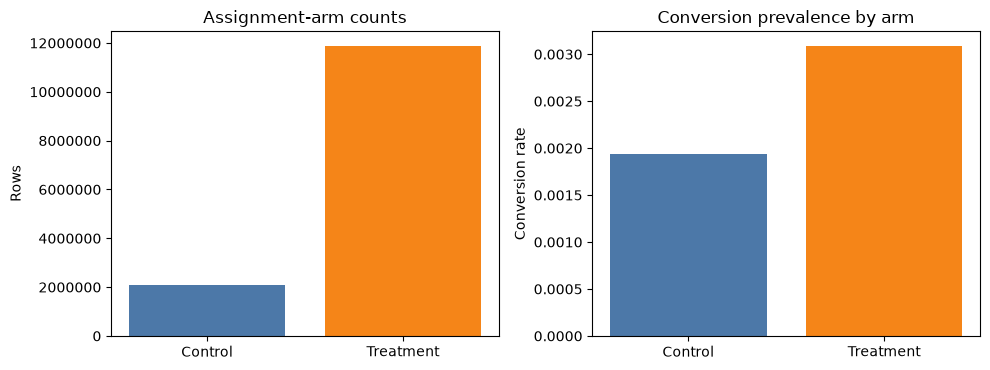


**Question:** Do both assignment arms and primary-outcome events have global empirical support?

**Observation:** Control has 2,096,937 rows and 4,063 conversions; treatment has 11,882,655 rows and 36,711 conversions.

**What this does NOT establish:** It does not prove randomization, exchangeability, causal identification, or local support for every future subgroup/top-K set.

**Implication:** Global arm and event counts support feasibility of the pre-specified primary outcome; local support must still be checked in any later split/fold/ranking analysis.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].bar(["Control", "Treatment"], [control_n, treated_n], color=["#4C78A8", "#F58518"])
axes[0].set_title("Assignment-arm counts")
axes[0].set_ylabel("Rows")
axes[0].ticklabel_format(axis="y", style="plain")
axes[1].bar(["Control", "Treatment"], [control_conversion_rate, treated_conversion_rate], color=["#4C78A8", "#F58518"])
axes[1].set_title("Conversion prevalence by arm")
axes[1].set_ylabel("Conversion rate")
fig.tight_layout()
plt.show()
display(Markdown(f'''
**Question:** Do both assignment arms and primary-outcome events have global empirical support?

**Observation:** Control has {control_n:,} rows and {control_conversions:,} conversions; treatment has {treated_n:,} rows and {treated_conversions:,} conversions.

**What this does NOT establish:** It does not prove randomization, exchangeability, causal identification, or local support for every future subgroup/top-K set.

**Implication:** Global arm and event counts support feasibility of the pre-specified primary outcome; local support must still be checked in any later split/fold/ranking analysis.
'''))


## 9. Repeated-profile and duplicate diagnostics

The primary policy is **KEEP ALL ROWS**. DP-02 through DP-05 and the available DP-07 precision comparison follow `docs/04_duplicate_profile_protocol.md`. Equal anonymous profiles are not called duplicate users. DP-06 awaits the frozen split and cannot be manufactured in this unsplit audit.

Grouping uses a disclosed deterministic 64-bit DuckDB hash for scalable potential-equality summaries; any adjudicated group would require exact column comparison.


In [ ]:
def duplicate_profile(definition, relation, group_exprs, treatment_expr, outcome_expr):
    t0 = time.perf_counter()
    profile_hash = "hash(" + ", ".join(group_exprs) + ")"
    query = f'''
        WITH profile_groups AS (
            SELECT {profile_hash} AS profile_hash, COUNT(*) AS n,
                   SUM({treatment_expr}) AS treated_n,
                   SUM({outcome_expr}) AS conversion_n
            FROM {relation}
            GROUP BY profile_hash
        )
        SELECT n > 1 AS repeated_profile,
               COUNT(*) AS profile_group_count,
               SUM(n) AS row_count,
               SUM(n - 1) AS rows_beyond_first,
               MAX(n) AS largest_group,
               SUM(treated_n) AS treated_count,
               SUM(conversion_n) AS conversion_count
        FROM profile_groups
        GROUP BY repeated_profile
        ORDER BY repeated_profile
    '''
    result = con.execute(query).fetchall()
    timings[f"duplicate {definition}"] = time.perf_counter() - t0
    mapped = {bool(r[0]): r[1:] for r in result}
    repeated = mapped.get(True, (0, 0, 0, 0, 0, 0))
    characteristics = []
    for repeated_flag, vals in mapped.items():
        groups, rows, beyond, largest, treated, converted = vals
        characteristics.append((definition, repeated_flag, groups, rows, treated, treated / rows if rows else None, converted, converted / rows if rows else None))
    return {
        "definition": definition,
        "duplicate_group_count": repeated[0],
        "rows_in_duplicate_groups": repeated[1],
        "rows_beyond_first": repeated[2],
        "largest_group": repeated[3],
        "characteristics": characteristics,
    }


q = lambda c: f'"{c}"'
raw_binary_t = f'COALESCE(TRY_CAST("{T_COLUMN}" AS BIGINT), 0)'
raw_binary_y = f'COALESCE(TRY_CAST("{Y_COLUMN}" AS BIGINT), 0)'

duplicate_results = [
    duplicate_profile("DP-02 exact loaded-value", "raw_text", [q(c) for c in EXPECTED_COLUMNS], raw_binary_t, raw_binary_y),
    duplicate_profile("DP-03 feature", "data", [q(c) for c in X_COLUMNS], q(T_COLUMN), q(Y_COLUMN)),
    duplicate_profile("DP-04 feature+treatment", "data", [q(c) for c in X_COLUMNS + [T_COLUMN]], q(T_COLUMN), q(Y_COLUMN)),
    duplicate_profile("DP-05 feature+treatment+outcome", "data", [q(c) for c in X_COLUMNS + [T_COLUMN, Y_COLUMN]], q(T_COLUMN), q(Y_COLUMN)),
]

duplicate_rows = [(
    r["definition"], r["duplicate_group_count"], r["rows_in_duplicate_groups"],
    r["rows_beyond_first"], r["largest_group"], r["rows_in_duplicate_groups"] / row_count
) for r in duplicate_results]
show_table(["Definition (64-bit hash grouped)", "Potential duplicate groups", "Rows in groups", "Rows beyond first", "Largest group", "Row fraction"], duplicate_rows)

characteristic_rows = [row for result in duplicate_results for row in result["characteristics"]]
show_table(["Definition", "Repeated?", "Profile groups", "Rows", "Treated", "Treatment rate", "Converters", "Conversion rate"], characteristic_rows)
print("Primary action: KEEP ALL ROWS. Hash-grouped repetition is an empirical profile property, not evidence of exact duplicated rows or duplicated users.")


| Definition (64-bit hash grouped) | Potential duplicate groups | Rows in groups | Rows beyond first | Largest group | Row fraction |
|---|---|---|---|---|---|
| DP-02 exact loaded-value | 961,605 | 2,221,150 | 1,259,545 | 12 | 0.158885 |
| DP-03 feature | 1,185,455 | 2,811,714 | 1,626,259 | 13 | 0.20113 |
| DP-04 feature+treatment | 970,146 | 2,240,397 | 1,270,251 | 12 | 0.160262 |
| DP-05 feature+treatment+outcome | 969,995 | 2,240,034 | 1,270,039 | 12 | 0.160236 |

| Definition | Repeated? | Profile groups | Rows | Treated | Treatment rate | Converters | Conversion rate |
|---|---|---|---|---|---|---|---|
| DP-02 exact loaded-value | 0 | 11,758,442 | 11,758,442 | 9,756,726 | 0.829764 | 40,774 | 0.00346764 |
| DP-02 exact loaded-value | 1 | 961,605 | 2,221,150 | 2,125,929 | 0.95713 | 0 | 0 |
| DP-03 feature | 0 | 11,167,878 | 11,167,878 | 9,497,164 | 0.8504 | 40,507 | 0.0036271 |
| DP-03 feature | 1 | 1,185,455 | 2,811,714 | 2,385,491 | 0.848412 | 267 | 9.49599e-05 |
| DP-04 feature+treatment | 0 | 11,739,195 | 11,739,195 | 9,737,685 | 0.829502 | 40,562 | 0.00345526 |
| DP-04 feature+treatment | 1 | 970,146 | 2,240,397 | 2,144,970 | 0.957406 | 212 | 9.46261e-05 |
| DP-05 feature+treatment+outcome | 0 | 11,739,558 | 11,739,558 | 9,738,041 | 0.829507 | 40,774 | 0.00347321 |
| DP-05 feature+treatment+outcome | 1 | 969,995 | 2,240,034 | 2,144,614 | 0.957402 | 0 | 0 |

Primary action: KEEP ALL ROWS. Hash-grouped repetition is an empirical profile property, not evidence of exact duplicated rows or duplicated users.


In [ ]:
# DP-07 precision comparison for feature profiles. The processed-Parquet leg is unavailable.
source_precision = duplicate_profile(
    "DP-07 source-text X precision", "raw_text", [q(c) for c in X_COLUMNS], raw_binary_t, raw_binary_y
)
float32_relation = "(SELECT treatment, conversion, " + ", ".join([f'CAST("{c}" AS FLOAT) AS "{c}"' for c in X_COLUMNS]) + " FROM data)"
float32_precision = duplicate_profile(
    "DP-07 float32 X projection", float32_relation, [q(c) for c in X_COLUMNS], q(T_COLUMN), q(Y_COLUMN)
)
float64_precision = next(r for r in duplicate_results if r["definition"].startswith("DP-03"))

precision_rows = [
    ("Source CSV textual precision", source_precision["duplicate_group_count"], source_precision["rows_in_duplicate_groups"], source_precision["rows_beyond_first"]),
    ("Primary float64 analytical precision", float64_precision["duplicate_group_count"], float64_precision["rows_in_duplicate_groups"], float64_precision["rows_beyond_first"]),
    ("Sensitivity float32 projection", float32_precision["duplicate_group_count"], float32_precision["rows_in_duplicate_groups"], float32_precision["rows_beyond_first"]),
    ("Processed Parquet", "NA", "NA", "NA — artifact unavailable"),
]
show_table(["Representation", "Duplicate groups", "Rows in groups", "Rows beyond first"], precision_rows)


| Representation | Duplicate groups | Rows in groups | Rows beyond first |
|---|---|---|---|
| Source CSV textual precision | 1,185,455 | 2,811,714 | 1,626,259 |
| Primary float64 analytical precision | 1,185,455 | 2,811,714 | 1,626,259 |
| Sensitivity float32 projection | 1,440,354 | 3,560,505 | 2,120,151 |
| Processed Parquet | NA | NA | NA — artifact unavailable |

## 10. Covariate balance diagnostics

Full-data SMD, variance ratios, quantile differences, and empirical ECDF/KS distances describe treatment-arm distributions. The `|SMD|=0.10` line is literature context only, never a causal-validity gate. Tiny p-values are not used mechanically on this approximately 14M-row artifact.

ED-03 project actions require the frozen development-only null calibration. ED-04 additionally requires the exact hashed cross-fitted LightGBM diagnostic pipeline. Neither is invented here.


In [ ]:
balance_exprs = []
for c in X_COLUMNS:
    qc = q(c)
    balance_exprs += [
        f"COUNT({qc}) AS {c}__n",
        f"AVG({qc}) AS {c}__mean",
        f"VAR_SAMP({qc}) AS {c}__var",
        f"approx_quantile({qc}, [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]) AS {c}__quantiles",
    ]
t0 = time.perf_counter()
cursor = con.execute(f"SELECT {T_COLUMN}, " + ", ".join(balance_exprs) + f" FROM data GROUP BY {T_COLUMN} ORDER BY {T_COLUMN}")
balance_records = cursor.fetchall()
balance_names = [d[0] for d in cursor.description]
by_arm = {int(row[0]): dict(zip(balance_names[1:], row[1:])) for row in balance_records}
timings["covariate balance moments"] = time.perf_counter() - t0

def empirical_ks_distance(column):
    qc = q(column)
    return con.execute(f'''
        WITH counts AS (
            SELECT {qc} AS value,
                   COUNT_IF({T_COLUMN} = 0)::DOUBLE AS n0,
                   COUNT_IF({T_COLUMN} = 1)::DOUBLE AS n1
            FROM data
            WHERE {qc} IS NOT NULL
            GROUP BY {qc}
        ), cdf AS (
            SELECT value,
                   SUM(n0) OVER (ORDER BY value ROWS UNBOUNDED PRECEDING) / SUM(n0) OVER () AS cdf0,
                   SUM(n1) OVER (ORDER BY value ROWS UNBOUNDED PRECEDING) / SUM(n1) OVER () AS cdf1
            FROM counts
        )
        SELECT MAX(ABS(cdf1 - cdf0)) FROM cdf
    ''').fetchone()[0]


t0 = time.perf_counter()
ks_by_feature = {c: empirical_ks_distance(c) for c in X_COLUMNS}
timings["covariate balance ECDF/KS"] = time.perf_counter() - t0

balance_rows = []
for c in X_COLUMNS:
    a0, a1 = by_arm[0], by_arm[1]
    mean_diff = a1[f"{c}__mean"] - a0[f"{c}__mean"]
    pooled_sd = math.sqrt((a1[f"{c}__var"] + a0[f"{c}__var"]) / 2)
    smd = mean_diff / pooled_sd if pooled_sd > 0 else None
    var_ratio = a1[f"{c}__var"] / a0[f"{c}__var"] if a0[f"{c}__var"] > 0 else None
    qdiff = [x - y for x, y in zip(a1[f"{c}__quantiles"], a0[f"{c}__quantiles"])]
    balance_rows.append((c, a1[f"{c}__n"], a0[f"{c}__n"], mean_diff, smd, abs(smd) if smd is not None else None, var_ratio, ks_by_feature[c], *qdiff))

show_table(
    ["Feature", "n treated", "n control", "Mean diff T-C", "SMD", "|SMD|", "Var ratio T/C", "ECDF/KS distance", "q01 diff~", "q05 diff~", "q25 diff~", "q50 diff~", "q75 diff~", "q95 diff~", "q99 diff~"],
    balance_rows,
)
max_abs_smd = max(row[5] for row in balance_rows if row[5] is not None)
max_smd_feature = max((row for row in balance_rows if row[5] is not None), key=lambda row: row[5])[0]
max_ks_feature = max(ks_by_feature, key=ks_by_feature.get)
max_ks = ks_by_feature[max_ks_feature]

diagnostic_rows = [
    ("Global arm support", "Executed", f"treated={treated_n:,}; control={control_n:,}", "PASS" if treated_n > 0 and control_n > 0 else "FAIL"),
    ("Covariate balance and ECDF/KS", "Executed", f"max |SMD|={max_abs_smd:.6g} ({max_smd_feature}); max KS={max_ks:.6g} ({max_ks_feature})", "INFO — NOT NULL-CALIBRATED"),
    ("ED-03 design-null calibration", "Not run", "2,000-replication calibration artifact absent", "WARN / OPEN_FOR_SPRINT2"),
    ("ED-04 X→T predictability", "Not run", "exact hashed classifier configuration and null calibration absent", "WARN / OPEN_FOR_SPRINT2"),
    ("Exposure consistency", "Executed", f"control rows with exposure=1: {control_exposed:,}", "INFO — audit-only"),
]
show_table(["Diagnostic", "Execution", "Evidence", "Disposition"], diagnostic_rows)


| Feature | n treated | n control | Mean diff T-C | SMD | \|SMD\| | Var ratio T/C | ECDF/KS distance | q01 diff~ | q05 diff~ | q25 diff~ | q50 diff~ | q75 diff~ | q95 diff~ | q99 diff~ |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| f0 | 11,882,655 | 2,096,937 | -0.0369497 | -0.00686562 | 0.00686562 | 0.995348 | 0.00895016 | 0 | 0 | 0.000525073 | -0.0483252 | -0.0313055 | -0.00280164 | -0.00176501 |
| f1 | 11,882,655 | 2,096,937 | 0.00240127 | 0.0239944 | 0.0239944 | 1.31645 | 0.00266241 | 0 | 0 | 0 | 0 | 0 | 0 | 0.348108 |
| f2 | 11,882,655 | 2,096,937 | -0.00187153 | -0.00624099 | 0.00624099 | 0.989375 | 0.00377462 | 0 | 0 | 0 | 8.83576e-06 | -0.00965754 | -0.00118317 | -0.000129406 |
| f3 | 11,882,655 | 2,096,937 | -0.0634093 | -0.0488363 | 0.0488363 | 1.18568 | 0.0137945 | -0.358066 | -0.400807 | 0 | 0 | 0 | 0 | 0 |
| f4 | 11,882,655 | 2,096,937 | 0.00271955 | 0.00796565 | 0.00796565 | 1.03235 | 0.00241219 | 0 | 0 | 0 | 0 | 0 | 0 | 0.0325384 |
| f5 | 11,882,655 | 2,096,937 | -0.0127363 | -0.0305568 | 0.0305568 | 1.22088 | 0.00609873 | -0.394844 | -0.834714 | 0 | 0 | 0 | 0 | 0 |
| f6 | 11,882,655 | 2,096,937 | -0.182913 | -0.0404481 | 0.0404481 | 1.07285 | 0.013069 | -0.676887 | -0.487567 | -0.17647 | -1.14562e-05 | -4.15856e-05 | 0 | 0 |
| f7 | 11,882,655 | 2,096,937 | 0.025271 | 0.0212695 | 0.0212695 | 1.08632 | 0.00609873 | 0 | 0 | 0 | 0 | 0 | 1.26414 | 0.0344811 |
| f8 | 11,882,655 | 2,096,937 | -0.00125989 | -0.0224333 | 0.0224333 | 1.05202 | 0.00833413 | -0.00335682 | -0.00473389 | -0.00298665 | 0 | 0 | 0 | 0 |
| f9 | 11,882,655 | 2,096,937 | 0.166336 | 0.0240011 | 0.0240011 | 1.0761 | 0.00712457 | 0 | 0 | 0 | 0 | 0 | 0.585996 | 0.452802 |
| f10 | 11,882,655 | 2,096,937 | 0.00176172 | 0.0105635 | 0.0105635 | 1.0513 | 0.00241451 | 0 | 0 | 0 | 0 | 0 | 0.000378045 | 0.00472256 |
| f11 | 11,882,655 | 2,096,937 | -0.000117058 | -0.00515953 | 0.00515953 | 1.03734 | 0.000914428 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |

| Diagnostic | Execution | Evidence | Disposition |
|---|---|---|---|
| Global arm support | Executed | treated=11,882,655; control=2,096,937 | PASS |
| Covariate balance and ECDF/KS | Executed | max \|SMD\|=0.0488363 (f3); max KS=0.0137945 (f3) | INFO — NOT NULL-CALIBRATED |
| ED-03 design-null calibration | Not run | 2,000-replication calibration artifact absent | WARN / OPEN_FOR_SPRINT2 |
| ED-04 X→T predictability | Not run | exact hashed classifier configuration and null calibration absent | WARN / OPEN_FOR_SPRINT2 |
| Exposure consistency | Executed | control rows with exposure=1: 0 | INFO — audit-only |

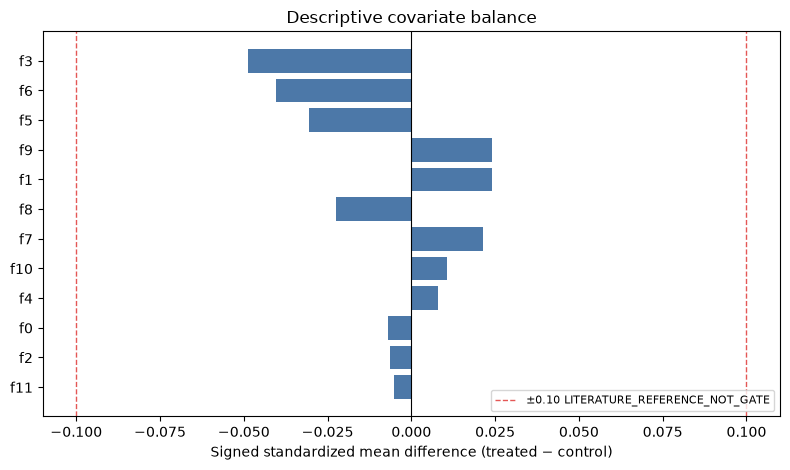


**Question:** Are marginal feature means broadly similar across assignment arms?

**Observation:** The largest observed absolute SMD is 0.0488363 for `f3`; the largest full-data empirical CDF/KS distance is 0.0137945 for `f3`. The ±0.10 line is shown only as `LITERATURE_REFERENCE_NOT_GATE`.

**What this does NOT establish:** Favorable balance cannot prove randomization or exchangeability. No project action status is assigned without the frozen design-consistent null calibration, and this SMD plot does not replace the reported ECDF/KS table or treatment-predictability evidence.

**Implication:** The observed moments are descriptive feasibility evidence only; the complete calibrated ED-03/ED-04 package remains `OPEN_FOR_SPRINT2`.


In [ ]:
plot_rows = sorted(balance_rows, key=lambda row: row[5])
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh([row[0] for row in plot_rows], [row[4] for row in plot_rows], color="#4C78A8")
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.10, color="#E45756", linestyle="--", linewidth=1, label="±0.10 LITERATURE_REFERENCE_NOT_GATE")
ax.axvline(-0.10, color="#E45756", linestyle="--", linewidth=1)
ax.set_xlabel("Signed standardized mean difference (treated − control)")
ax.set_title("Descriptive covariate balance")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()
display(Markdown(f'''
**Question:** Are marginal feature means broadly similar across assignment arms?

**Observation:** The largest observed absolute SMD is {max_abs_smd:.6g} for `{max_smd_feature}`; the largest full-data empirical CDF/KS distance is {max_ks:.6g} for `{max_ks_feature}`. The ±0.10 line is shown only as `LITERATURE_REFERENCE_NOT_GATE`.

**What this does NOT establish:** Favorable balance cannot prove randomization or exchangeability. No project action status is assigned without the frozen design-consistent null calibration, and this SMD plot does not replace the reported ECDF/KS table or treatment-predictability evidence.

**Implication:** The observed moments are descriptive feasibility evidence only; the complete calibrated ED-03/ED-04 package remains `OPEN_FOR_SPRINT2`.
'''))


## 11. Computational feasibility

Runtime is recorded for full-data operations. The audit uses streaming DuckDB scans and aggregations and does not create a redundant complete pandas copy. The memory figure is a transparent dense-payload lower bound, not measured peak RSS.


In [ ]:
dense_payload_bytes = row_count * (12 * 8 + 4 * 8 + 8)  # 12 float64, 4 int64, run-local int64 identity
timing_rows = [(name, row_count, seconds) for name, seconds in timings.items()]
show_table(["Measured operation", "Rows scanned/represented", "Seconds"], timing_rows)
show_table(["Property", "Observed/estimated"], [
    ("Canonical compressed artifact", f"{gzip_size / 2**20:.3f} MiB"),
    ("Working CSV artifact", f"{file_size / 2**30:.3f} GiB"),
    ("Rows", row_count),
    ("Dense typed payload lower-bound", f"{dense_payload_bytes / 2**30:.3f} GiB (excludes dataframe/engine overhead)"),
    ("Execution engine", f"DuckDB {duckdb.__version__}, four threads, 6 GiB engine limit"),
    ("Execution strategy", "streaming scans/aggregations; no complete pandas dataframe"),
    ("Temporary spill location", portable_path(DUCKDB_TEMP_DIR)),
])


| Measured operation | Rows scanned/represented | Seconds |
|---|---|---|
| full CSV row-count scan | 13,979,592 | 9.42421 |
| canonical .csv.gz SHA-256 | 13,979,592 | 0.313377 |
| working CSV SHA-256 | 13,979,592 | 3.17831 |
| streamed gzip-content SHA-256 | 13,979,592 | 8.53237 |
| missing/invalid-value audit | 13,979,592 | 18.884 |
| feature characterization | 13,979,592 | 20.2115 |
| treatment allocation | 13,979,592 | 8.29785 |
| primary outcome support | 13,979,592 | 8.06625 |
| duplicate DP-02 exact loaded-value | 13,979,592 | 14.7786 |
| duplicate DP-03 feature | 13,979,592 | 17.7028 |
| duplicate DP-04 feature+treatment | 13,979,592 | 16.2401 |
| duplicate DP-05 feature+treatment+outcome | 13,979,592 | 16.7533 |
| duplicate DP-07 source-text X precision | 13,979,592 | 13.2829 |
| duplicate DP-07 float32 X projection | 13,979,592 | 16.5242 |
| covariate balance moments | 13,979,592 | 21.4933 |
| covariate balance ECDF/KS | 13,979,592 | 114.593 |

| Property | Observed/estimated |
|---|---|
| Canonical compressed artifact | 296.996 MiB |
| Working CSV artifact | 3.025 GiB |
| Rows | 13,979,592 |
| Dense typed payload lower-bound | 1.771 GiB (excludes dataframe/engine overhead) |
| Execution engine | DuckDB 1.5.5, four threads, 6 GiB engine limit |
| Execution strategy | streaming scans/aggregations; no complete pandas dataframe |
| Temporary spill location | outputs/audit/duckdb_temp |

## 12. Sprint 1 empirical findings

The compact evidence table separates completed checks from genuine limitations. `PASS` is scoped to executed checks, `WARN` identifies incomplete or cautionary evidence, and `FAIL` records a material hard contradiction.


In [ ]:
schema_pass = not missing_required and not unexpected_columns and not index_like and actual_columns == EXPECTED_COLUMNS
binary_valid = all(audit[f"{c}__missing"] == 0 and audit[f"{c}__malformed"] == 0 and audit[f"{c}__invalid_binary"] == 0 for c in BINARY_COLUMNS)
features_valid = all(audit[f"{c}__missing"] == 0 and audit[f"{c}__malformed"] == 0 and audit[f"{c}__nan"] == 0 and audit[f"{c}__posinf"] == 0 and audit[f"{c}__neginf"] == 0 for c in X_COLUMNS)
global_support = treated_n > 0 and control_n > 0
event_support = all(joint_lookup.get((t, y), 0) > 0 for t in (0, 1) for y in (0, 1))
duplicates_present = any(r["rows_in_duplicate_groups"] > 0 for r in duplicate_results)
full_row_count_pass = row_count == EXPECTED_FULL_ROW_COUNT
manifest_pass = manifest_path.is_file() and bool(gzip_sha256)

summary_rows = [
    ("Canonical compressed provenance", "PASS" if manifest_pass else "FAIL", f"{CANONICAL_GZIP_PATH.name}; SHA-256 recorded in {portable_path(manifest_path)}."),
    ("Decompressed CSV reconciliation", "PASS" if decompressed_reconciliation else "FAIL", "Streamed gzip content hash equals working CSV hash." if decompressed_reconciliation else "Byte hashes differ; do not continue to modeling."),
    ("Full row count", "PASS" if full_row_count_pass else "FAIL", f"Audited {row_count:,} rows; primary audit has no 2M cap."),
    ("Schema", "PASS" if schema_pass else "FAIL", "Expected 16-column release schema and no accidental index/unexpected columns."),
    ("X/T/Y availability", "PASS" if feature_contract_pass else "FAIL", "Exact X=f0…f11, T=treatment, primary Y=conversion; exposure excluded from X."),
    ("Invalid/missing values", "PASS" if binary_valid and features_valid else "FAIL", f"Total findings={quality_failures:,}; no values imputed or deleted."),
    ("Duplicate protocol", "WARN" if duplicates_present else "PASS", "64-bit hash-grouped potential repetitions; all rows retained; no duplicate-user claim; DP-06 awaits the frozen split."),
    ("Treatment/control support", "PASS" if global_support else "FAIL", f"treated={treated_n:,}; control={control_n:,}."),
    ("Primary outcome event support", "PASS" if event_support else "FAIL", "All four global (T,Y) cells are non-empty."),
    ("Causal-data diagnostics", "WARN", "SMD, variance ratio, quantiles, full-data ECDF/KS, support, and exposure diagnostics executed; design-null calibration and ED-04 predictability remain unexecuted."),
    ("Computational feasibility", "PASS", "Full 13.98M-row structural and aggregate audit completed without a redundant full pandas copy."),
]
show_table(["Evidence item", "Status", "Basis"], summary_rows)
status_counts = {s: sum(row[1] == s for row in summary_rows) for s in ("PASS", "WARN", "FAIL")}
show_table(["Status", "Count"], status_counts.items())


| Evidence item | Status | Basis |
|---|---|---|
| Canonical compressed provenance | PASS | criteo-uplift-v2.1.csv.gz; SHA-256 recorded in outputs/audit/dataset_manifest.json. |
| Decompressed CSV reconciliation | PASS | Streamed gzip content hash equals working CSV hash. |
| Full row count | PASS | Audited 13,979,592 rows; primary audit has no 2M cap. |
| Schema | PASS | Expected 16-column release schema and no accidental index/unexpected columns. |
| X/T/Y availability | PASS | Exact X=f0…f11, T=treatment, primary Y=conversion; exposure excluded from X. |
| Invalid/missing values | PASS | Total findings=0; no values imputed or deleted. |
| Duplicate protocol | WARN | 64-bit hash-grouped potential repetitions; all rows retained; no duplicate-user claim; DP-06 awaits the frozen split. |
| Treatment/control support | PASS | treated=11,882,655; control=2,096,937. |
| Primary outcome event support | PASS | All four global (T,Y) cells are non-empty. |
| Causal-data diagnostics | WARN | SMD, variance ratio, quantiles, full-data ECDF/KS, support, and exposure diagnostics executed; design-null calibration and ED-04 predictability remain unexecuted. |
| Computational feasibility | PASS | Full 13.98M-row structural and aggregate audit completed without a redundant full pandas copy. |

| Status | Count |
|---|---|
| PASS | 9 |
| WARN | 2 |
| FAIL | 0 |

## 13. Handoff to modeling

This notebook ends at data-integrity and feasibility evidence. It does not train response, T/X, Causal Forest, DR, or S-Learner models and does not access held-out evaluation.


In [ ]:
fail_count = status_counts["FAIL"]
material_contradiction = fail_count > 0
total_runtime = time.perf_counter() - NOTEBOOK_START

if material_contradiction:
    conclusion = (
        "A material contradiction was detected in one or more hard feasibility checks. "
        "The frozen Sprint 1 decisions have not been modified; review the failing evidence before downstream modeling."
    )
else:
    conclusion = (
        "The canonical compressed artifact is locally frozen by SHA-256 and reconciles byte-for-byte, after streaming decompression, "
        "to the working CSV. Full 13.98M-row structural and aggregate auditing is computationally feasible. "
        "No finding in this evidence pass requires reopening the frozen research question or primary duplicate policy. "
        "The design-calibrated ED-03/ED-04 package and processed analytical lineage remain later pre-test requirements."
    )

display(Markdown(f"**Conclusion:** {conclusion}"))
show_table(["Run property", "Value"], [
    ("Rows actually audited", row_count),
    ("Notebook runtime through conclusion", f"{total_runtime:.1f} seconds"),
    ("Held-out model evaluation", "NOT PERFORMED"),
    ("Model training", "NOT PERFORMED"),
    ("Rows removed/imputed", 0),
    ("Frozen methodology changed", "NO"),
])
display(Markdown(
    "**Handoff:** Proceed only through the frozen development sequence: response baseline → T-Learner → "
    "X-Learner → promotion-gated Causal Forest → evaluation/robustness. S-Learner remains deferred and "
    "DR-Learner remains conditional. The held-out test stays sealed until the pre-test executable freeze."
))

con.close()
print("DuckDB connection closed cleanly.")


**Conclusion:** The canonical compressed artifact is locally frozen by SHA-256 and reconciles byte-for-byte, after streaming decompression, to the working CSV. Full 13.98M-row structural and aggregate auditing is computationally feasible. No finding in this evidence pass requires reopening the frozen research question or primary duplicate policy. The design-calibrated ED-03/ED-04 package and processed analytical lineage remain later pre-test requirements.

| Run property | Value |
|---|---|
| Rows actually audited | 13,979,592 |
| Notebook runtime through conclusion | 336.3 seconds |
| Held-out model evaluation | NOT PERFORMED |
| Model training | NOT PERFORMED |
| Rows removed/imputed | 0 |
| Frozen methodology changed | NO |

**Handoff:** Proceed only through the frozen development sequence: response baseline → T-Learner → X-Learner → promotion-gated Causal Forest → evaluation/robustness. S-Learner remains deferred and DR-Learner remains conditional. The held-out test stays sealed until the pre-test executable freeze.

DuckDB connection closed cleanly.
